**Objective:**

The objective of this assignment is to perform Exploratory Data Analysis (EDA), data preprocessing, feature engineering, and predictive modeling on the Tesla Deliveries dataset. This includes understanding data patterns, handling missing values, visualizing insights, creating time-based features, and training machine learning models to predict estimated deliveries accurately.

**1.Importing Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

from statsmodels.tsa.stattools import adfuller

**Explanation:**

Imported all required libraries for data handling, visualization, preprocessing, machine learning, and stationarity testing.

**2.Loading the Dataset and Understanding Dataset Structure**

In [ ]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
print(df.head())
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


**Explanation:**

Loaded the dataset into a DataFrame and displayed first 5 rows.
Checked dimensions, datatypes, and statistical summary.

**3.Checking Missing Values and Duplicates**

In [ ]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicate rows: 0


**Explanation:**

This helps identify missing values in each column and ensures dataset quality by detecting duplicate entries.

**4. Data Visualization: Model-wise Delivery Analysis**

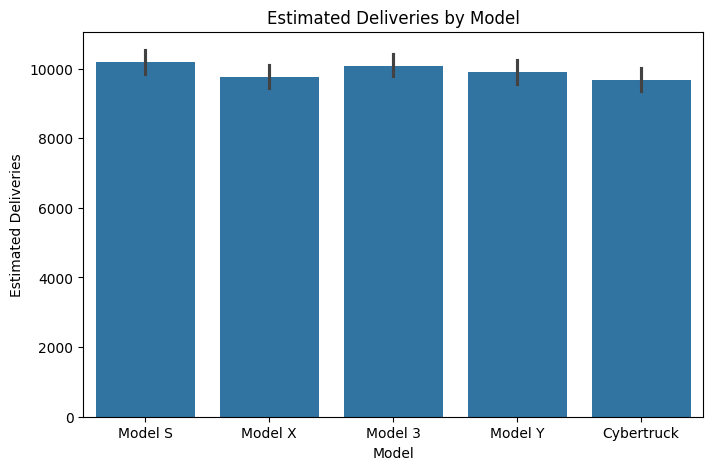

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries'
)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

**Explanation:**

This bar chart shows the estimated deliveries for different Tesla vehicle models.
It helps identify which models contribute the most to total deliveries.

**5. Data Visualization: Region-wise Delivery Analysis**

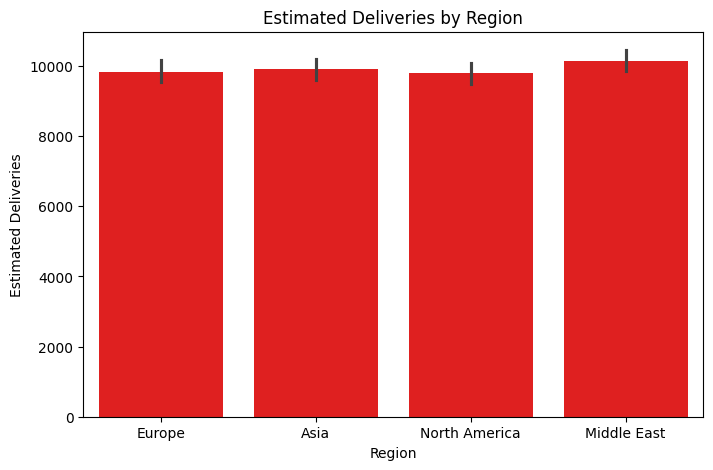

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    color = 'red'
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()

**Explanation:**

This graph compares delivery distribution across different regions.
It helps analyze regional demand patterns.

**6. Correlation Analysis using Heatmap**

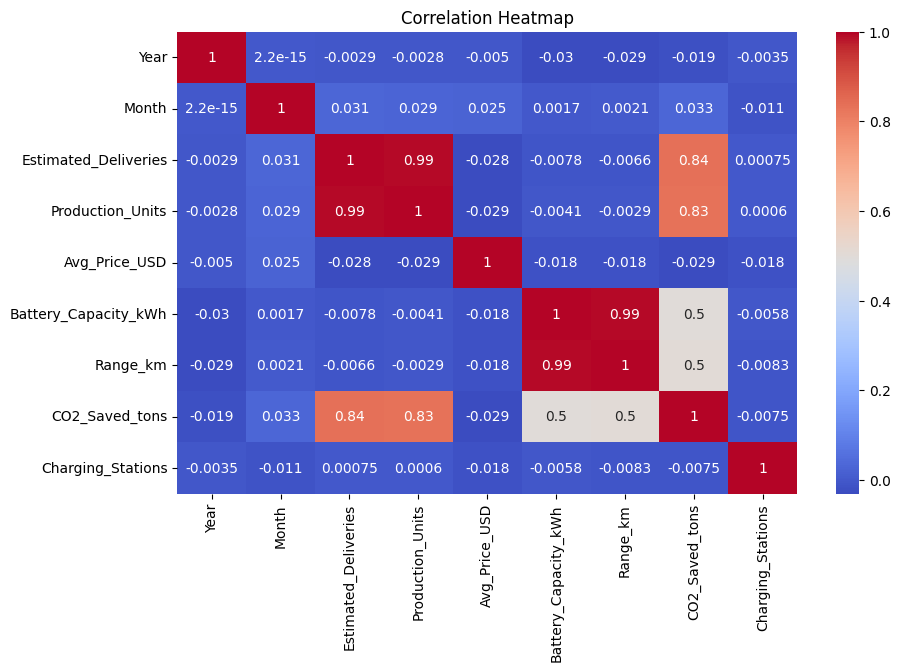

In [ ]:
num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

**Explanation:**

The heatmap shows the correlation between numerical features.
It helps identify strong positive or negative relationships between variables.

**7. Production vs Estimated Deliveries Analysis**

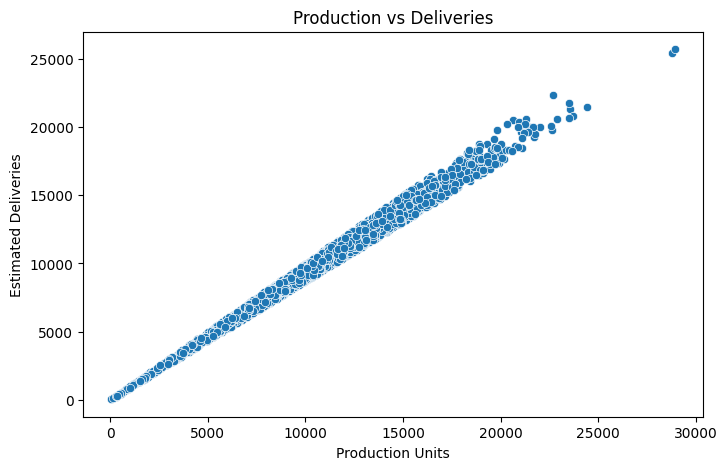

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

**Explanation:**

This scatter plot visualizes the relationship between production units and estimated deliveries.
It helps understand whether higher production leads to higher deliveries.

**8. Yearly Delivery Trend Analysis**

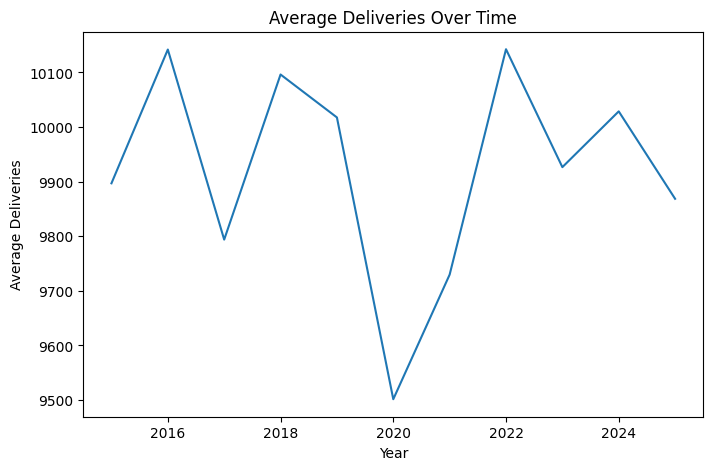

In [ ]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries'
)

plt.title("Average Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")

plt.show()

**Explanation:**

This line graph shows the yearly trend of average Tesla deliveries.
It helps identify long-term growth patterns.

**9. Encoding Categorical Features**

In [ ]:

encoder_obj = LabelEncoder()

cat_features = ['Region', 'Model', 'Source_Type']

for feature in cat_features:
    df[feature] = encoder_obj.fit_transform(df[feature])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


**Explanation:**

Machine learning models work with numerical values.
So categorical columns were transformed into integer labels.

**10. Feature Engineering: Creating Previous Month Delivery Feature**

In [ ]:
df['prev_month_delivery'] = df['Estimated_Deliveries'].shift(1)

df['prev_month_delivery'].fillna(
    df['prev_month_delivery'].median(),
    inplace=True
)

**Explanation:**

A lag feature was created to capture previous delivery values.
This helps the model learn temporal dependencies.

**11. Feature Engineering: Rolling Average Calculation**

In [ ]:
df['delivery_avg_window'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['delivery_avg_window'].fillna(
    df['delivery_avg_window'].median(),
    inplace=True
)

**Explanation:**

Rolling average smooths out short-term fluctuations and captures recent delivery trends.
This improves forecasting capability.

**12. Preview of Engineered Features**

In [ ]:
print(
    df[
        ['Estimated_Deliveries',
         'prev_month_delivery',
         'delivery_avg_window']
    ].head()
)

   Estimated_Deliveries  prev_month_delivery  delivery_avg_window
0                 17646               9860.0          9898.333333
1                  3797              17646.0          9898.333333
2                  8411               3797.0          9951.333333
3                  6555               8411.0          6254.333333
4                 12374               6555.0          9113.333333


**Explanation:**

This step verifies the newly created lag and rolling features.
It ensures feature engineering has been applied correctly.

**13. Defining Features and Target Variable**

In [ ]:
target_column = df['Estimated_Deliveries']

input_features = df.drop(
    columns=['Estimated_Deliveries']
)

**Explanation:**

The target variable contains the delivery values to be predicted.
The remaining columns are used as input features for training.

**14. Splitting Dataset into Training and Testing Sets**

In [ ]:
cutoff_point = int(len(df) * 0.80)

X_train = input_features.iloc[:cutoff_point]
X_test = input_features.iloc[cutoff_point:]

y_train = target_column.iloc[:cutoff_point]
y_test = target_column.iloc[cutoff_point:]

**Explanation:**

The dataset was split into 80% training and 20% testing data.
Chronological order was maintained to preserve time-series structure.

**15. Model Training and Prediction**

In [ ]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

linear_predictions = baseline_model.predict(X_test)

**Explanation:**

Linear Regression was used as the baseline forecasting model.
It establishes an initial benchmark for performance comparison.

**16. Model Evaluation**

In [ ]:
mae_score = mean_absolute_error(y_test, linear_predictions)
rmse_score = np.sqrt(mean_squared_error(y_test, linear_predictions))
r2_value = r2_score(y_test, linear_predictions)

print("MAE:", mae_score)
print("RMSE:", rmse_score)
print("R2 Score:", r2_value)

MAE: 310.3344143333054
RMSE: 375.5645535910335
R2 Score: 0.9908058776640247


**Explanation:**

MAE, RMSE, and R² were calculated to evaluate prediction performance.
These metrics measure prediction accuracy and model fit.

**17.Actual and Predicted Comparision**

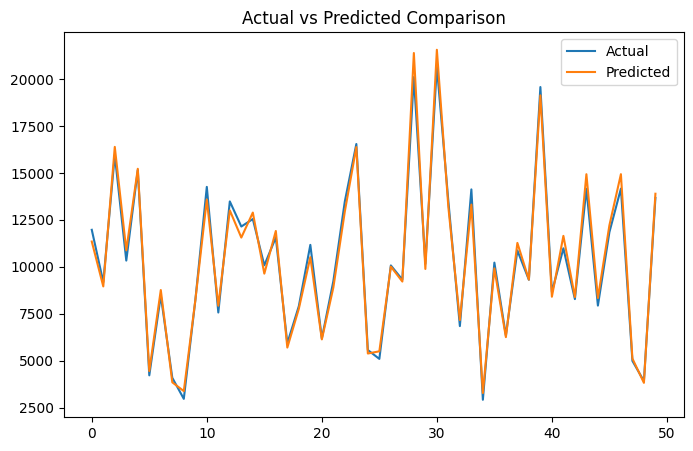

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    y_test.values[:50],
    label='Actual'
)

plt.plot(
    linear_predictions[:50],
    label='Predicted'
)

plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.show()

**Explanation:**

This graph compares actual values with predicted values from Linear Regression.
It helps visualize how close the predictions are to the real data.

**18.Calculation of Validation and Average scores**

In [ ]:
from sklearn.model_selection import cross_val_score

validation_scores = cross_val_score(
    baseline_model,
    input_features,
    target_column,
    cv=5,
    scoring='r2'
)

print("Validation Scores:", validation_scores)
print("Average Score:", validation_scores.mean())

Validation Scores: [0.99064904 0.99046596 0.98949293 0.990511   0.99080588]
Average Score: 0.9903849607056949


**Explanation:**

Cross-validation evaluates model performance across multiple folds.
R² scoring helps check consistency and reliability.

**19.Applying GridSearchCV to Find Optimal Random Forest Parameters**

In [ ]:
search_params = {
    'n_estimators': [80, 120],
    'max_depth': [6, 12, None]
}

forest_model = RandomForestRegressor(random_state=10)

grid_search = GridSearchCV(
    estimator=forest_model,
    param_grid=search_params,
    cv=4
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=10),
             param_grid={'max_depth': [6, 12, None], 'n_estimators': [80, 120]})

**Explanation:**

GridSearchCV tests multiple parameter combinations to find the best Random Forest configuration.This helps optimize model performance.

**20.Displaying Best Hyperparameters**

In [ ]:
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': None, 'n_estimators': 80}


**Explanation:**

This step displays the best hyperparameters selected for the Random Forest model.
These settings are used for final prediction.

**21. Random Forest Prediction and Model Evaluation**

In [ ]:
best_rf = grid_search.best_estimator_

rf_pred = best_rf.predict(X_test)

print(
    r2_score(y_test,rf_pred)
)


0.9902890108175867


**Explanation:**

The optimized Random Forest model was used for prediction.
R² score was calculated to measure how well the model fits the test data.

**22.Plotting Top 10 Important Features**

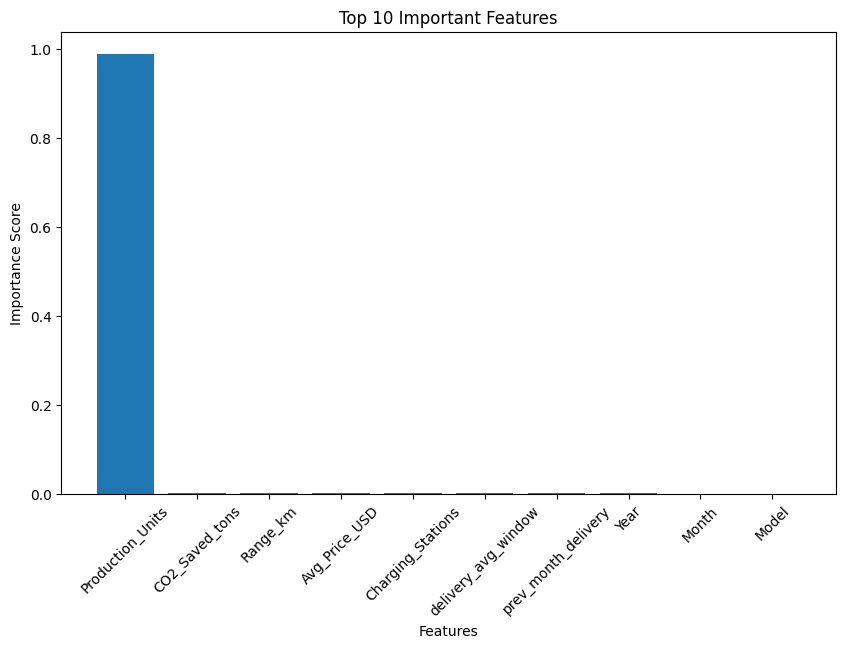

In [ ]:
feature_scores = pd.DataFrame({
    'Feature': input_features.columns,
    'Importance': best_rf.feature_importances_
})

top_10_features = feature_scores.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_10_features['Feature'],
    top_10_features['Importance']
)

plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

**Explanation:**

Feature importance scores show how much each feature contributes to prediction.
The top 10 most important features were visualized.

In [ ]:
print(df['Production_Units'].corr(df['Estimated_Deliveries']))

0.9942343488939529


**Explanation:**

This step calculates the correlation between Production Units and Estimated Deliveries.
It helps measure their linear relationship strength.

In [ ]:
top_10_features

,Feature,Importance
4,Production_Units,0.990204
8,CO2_Saved_tons,0.002125
7,Range_km,0.001180
5,Avg_Price_USD,0.001122
10,Charging_Stations,0.000957
12,delivery_avg_window,0.000938
11,prev_month_delivery,0.000859
0,Year,0.000788
1,Month,0.000664
3,Model,0.000375


**Explanation:**

This table lists the top 10 most important features ranked by their importance scores.
It provides a detailed feature contribution summary.

**23. Augmented Dickey-Fuller (ADF) Test for Stationarity**

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_output = adfuller(
    df['Estimated_Deliveries']
)

print("ADF Statistic:", adf_output[0])
print("P-value:", adf_output[1])

ADF Statistic: -53.82661259715622
P-value: 0.0


**Explanation:**

The Augmented Dickey-Fuller test checks whether the time-series data is stationary.
Stationarity is important for reliable forecasting.

**24. Interpreting ADF Test Results**

In [ ]:
if adf_output[1] < 0.05:
    print("The delivery trend is stationary")
else:
    print("The delivery trend is non-stationary")

The delivery trend is stationary


**Explanation:**

If the p-value is below 0.05, the data is stationary.
Otherwise, it is considered non-stationary.

**25. Forecast Comparison Table (Actual vs Predicted Values)**

In [ ]:
forecast_summary = pd.DataFrame({
    'Actual_Values': y_test.values,
    'Predicted_Values': rf_pred
})

forecast_summary['Prediction_Error'] = (
    forecast_summary['Actual_Values']
    -
    forecast_summary['Predicted_Values']
)

forecast_summary.head(20)

,Actual_Values,Predicted_Values,Prediction_Error
0,11974,11225.9375,748.0625
1,9189,9033.9500,155.0500
2,15956,16808.3500,-852.3500
3,10336,10894.6375,-558.6375
4,15152,15709.4000,-557.4000
5,4224,3963.2375,260.7625
6,8475,8872.9500,-397.9500
7,4093,3829.5000,263.5000
8,2972,3127.2500,-155.2500
9,8208,8099.9500,108.0500


**Explanation:**

This table compares actual delivery values with predicted values.
It also shows the prediction error for each observation.

# Conclusion

In this assignment, Tesla delivery data was analyzed using exploratory data analysis techniques to identify trends, regional distributions, and model-level patterns.

Feature engineering techniques such as lag features and rolling averages were applied to improve the model’s ability to capture time-based dependencies.

Linear Regression was used as the baseline model, while Random Forest with hyperparameter tuning achieved better performance due to its ability to capture complex relationships.

Feature importance analysis identified the most influential variables affecting delivery predictions.

Finally, the ADF test was used to check stationarity, and the forecast comparison table demonstrated the effectiveness of the trained model in predicting future Tesla deliveries.